## CSI-RS Timing Configurations

This notebook demonstrates how CSI-RS timing is configured and visualized in **NeoRadium**.

The examples use a periodic NZP CSI-RS resource based on row 3 of 3GPP TS 38.211, Table 7.4.1.5.3-1, and show how the CSI-RS appears in different slots depending on its timing parameters.

The notebook focuses on:

- CSI-RS resource type: periodic NZP CSI-RS
- Slot period configuration
- Slot offset configuration
- How period and offset determine which slots contain CSI-RS
- Visualization of CSI-RS resource placement across consecutive slots

By comparing the generated slot maps, you can see how changing the CSI-RS offset or period shifts the slots in which CSI-RS resources are transmitted, while the resource-element pattern within each active slot remains the same.

In [1]:
import numpy as np
import scipy.io

from neoradium import Carrier, PDSCH, Grid, CsiRsConfig, CsiRsSet

In [2]:
carrier = Carrier(startRb=0, numRbs=24, spacing=15)
bwp = carrier.bwps[0]
bwp.print()



Bandwidth Part Properties:
  Resource Blocks:    24 RBs starting at 0 (288 subcarriers)
  Subcarrier Spacing: 15 kHz
  CP Type:            normal
  Interleaving:       No
  Bandwidth:          4.32 MHz
  symbolsPerSlot:     14
  slotsPerSubFrame:   1
  nFFT:               2048
  frameNo:            0
  slotNo:             0




CSI-RS Configuration: (1 Resource Sets)
  CSI-RS Resource Set 0:(1 NZP resources)
    Resource Set ID:      0
    Resource Type:        periodic
    Resource Blocks:      24 RBs starting at 0
    Slot Period:          4
    Num CSI-RS:           1
    CSI-RS 0:
      resourceId:         0
      numPorts:           2
      cdmSize:            2 (fd-CDM2)
      density:            1
      RE Indices:         6
      Symbol Indices:     3
      Table Row:          3
      Slot Offset:        0
      Power:              0 dB
      scramblingID:       0



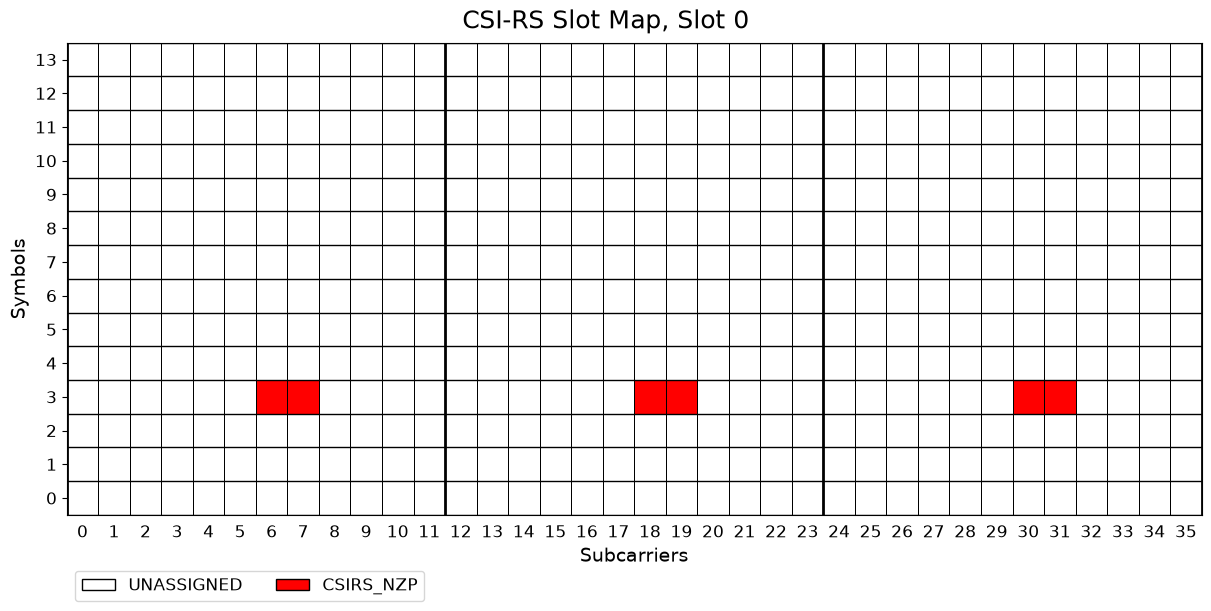

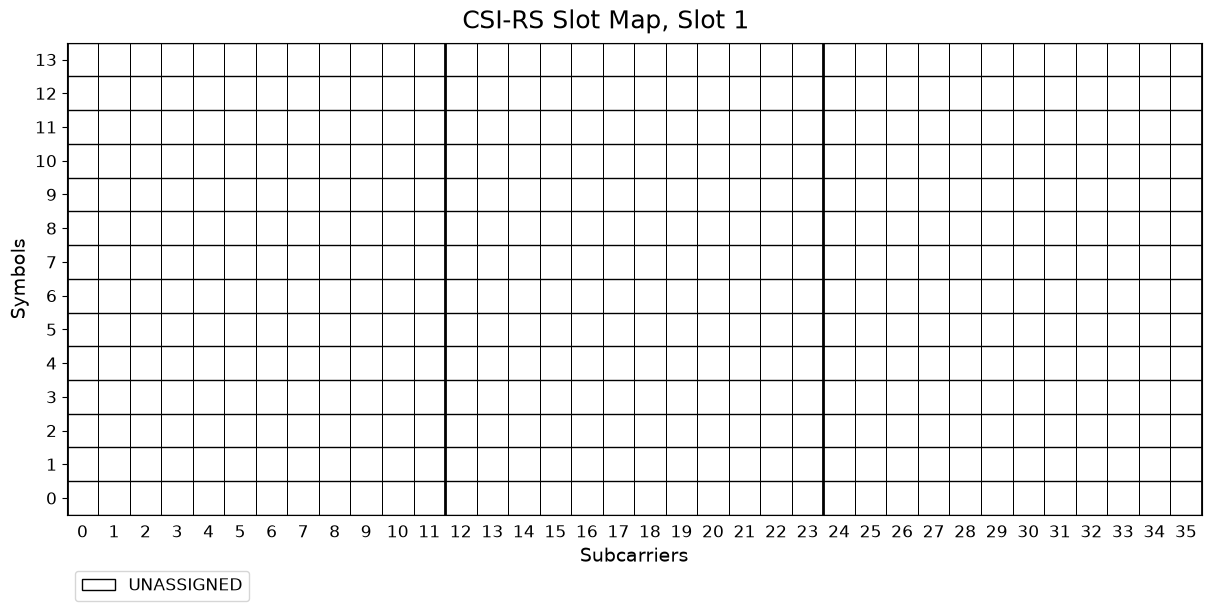

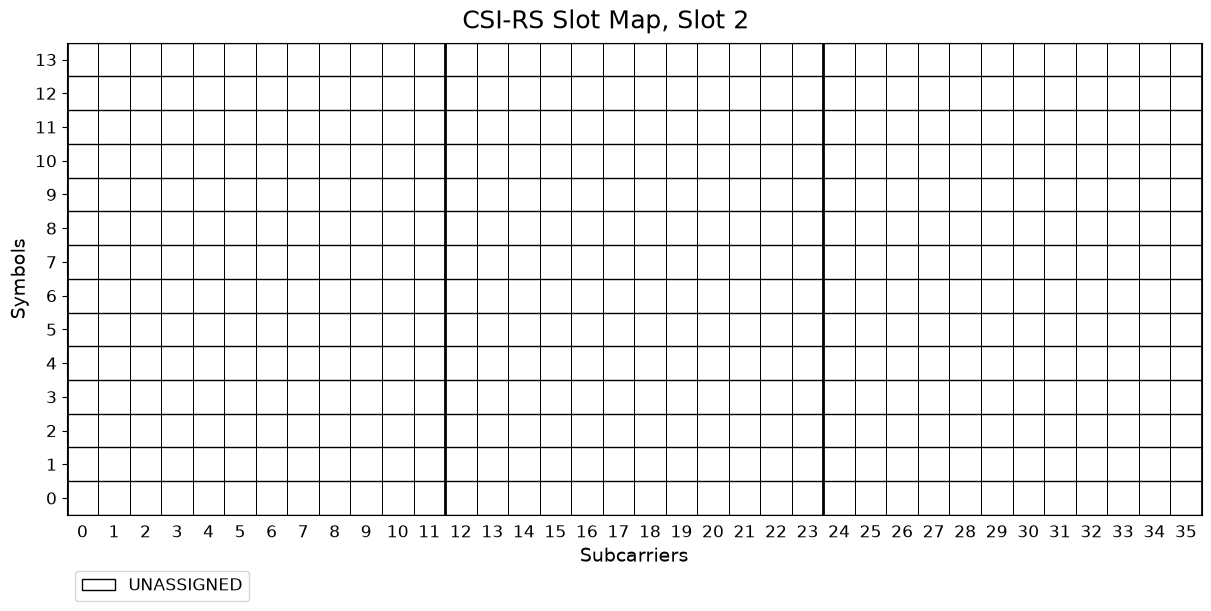

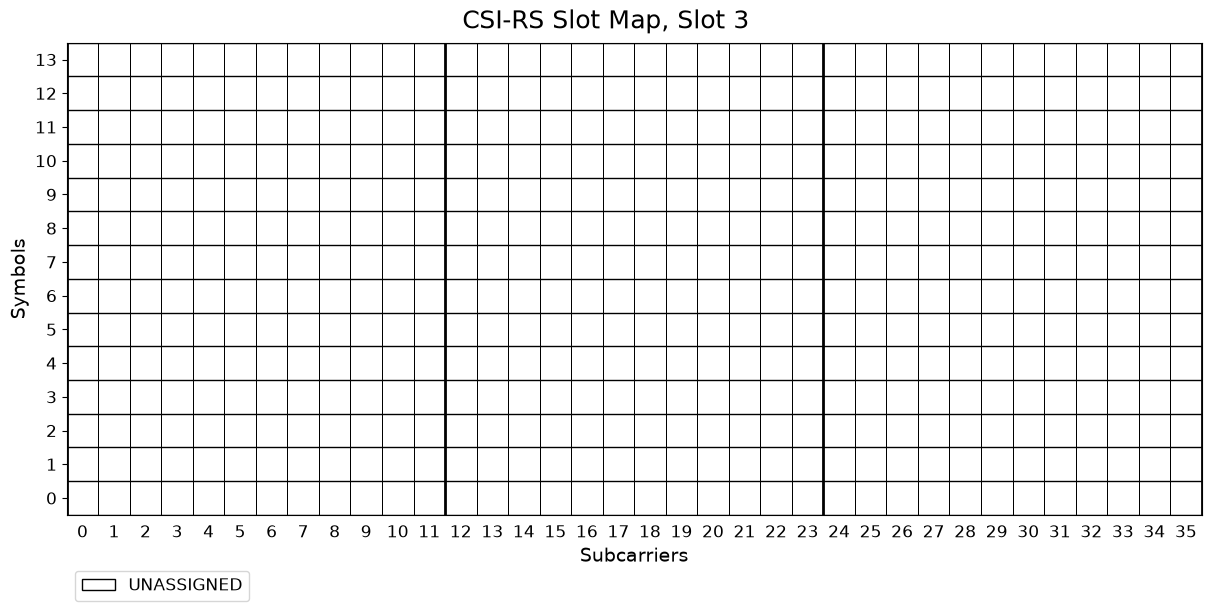

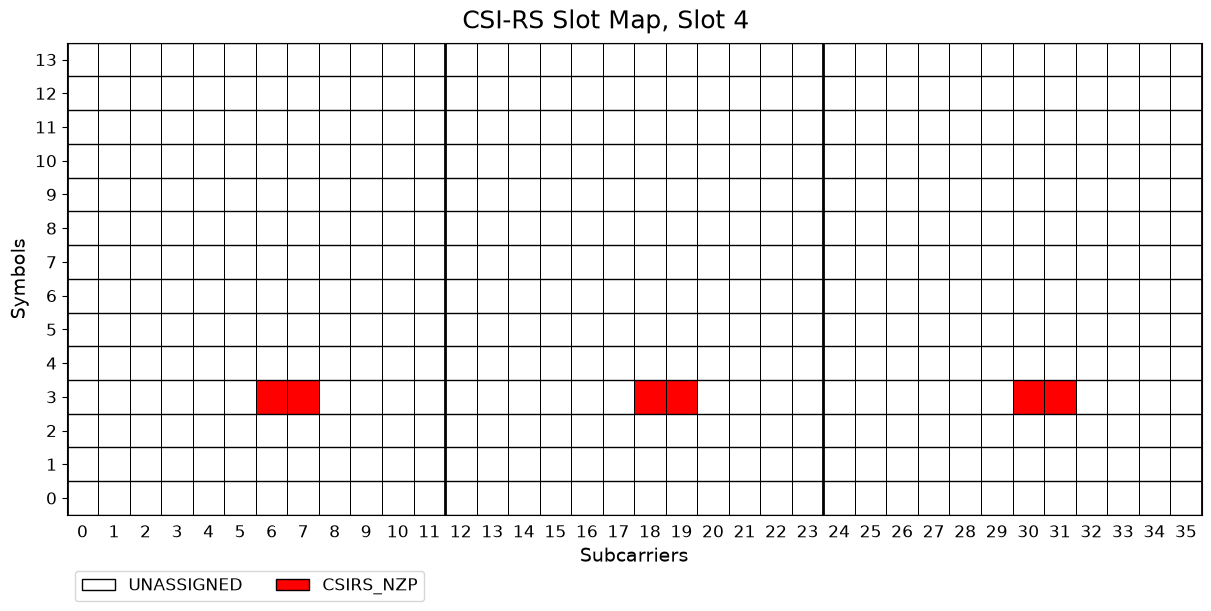

In [3]:
# Using row 3 of 3GPP 38.211 Table 7.4.1.5.3-1
# The default setting is a 'Periodic' resource type with `period=4` and `offset=0`, meaning 
# slots 0, 4, and so on contain CSI-RS.
csiRsConfig = CsiRsConfig([CsiRsSet("NZP", bwp, symbols=[3], numPorts=2)])
csiRsConfig.print()

carrier.slotNo = 0
for slot in range(5):
    grid = bwp.createGrid(csiRsConfig.numPorts)
    csiRsConfig.populateGrid(grid)
    # Show only the first port
    grid.drawMap(rbRange=(0,2), title="CSI-RS Slot Map, Slot %d"%(carrier.slotNo))  
    carrier.slotNo += 1


CSI-RS Configuration: (1 Resource Sets)
  CSI-RS Resource Set 0:(1 NZP resources)
    Resource Set ID:      0
    Resource Type:        periodic
    Resource Blocks:      24 RBs starting at 0
    Slot Period:          4
    Num CSI-RS:           1
    CSI-RS 0:
      resourceId:         0
      numPorts:           2
      cdmSize:            2 (fd-CDM2)
      density:            1
      RE Indices:         6
      Symbol Indices:     3
      Table Row:          3
      Slot Offset:        1
      Power:              0 dB
      scramblingID:       0



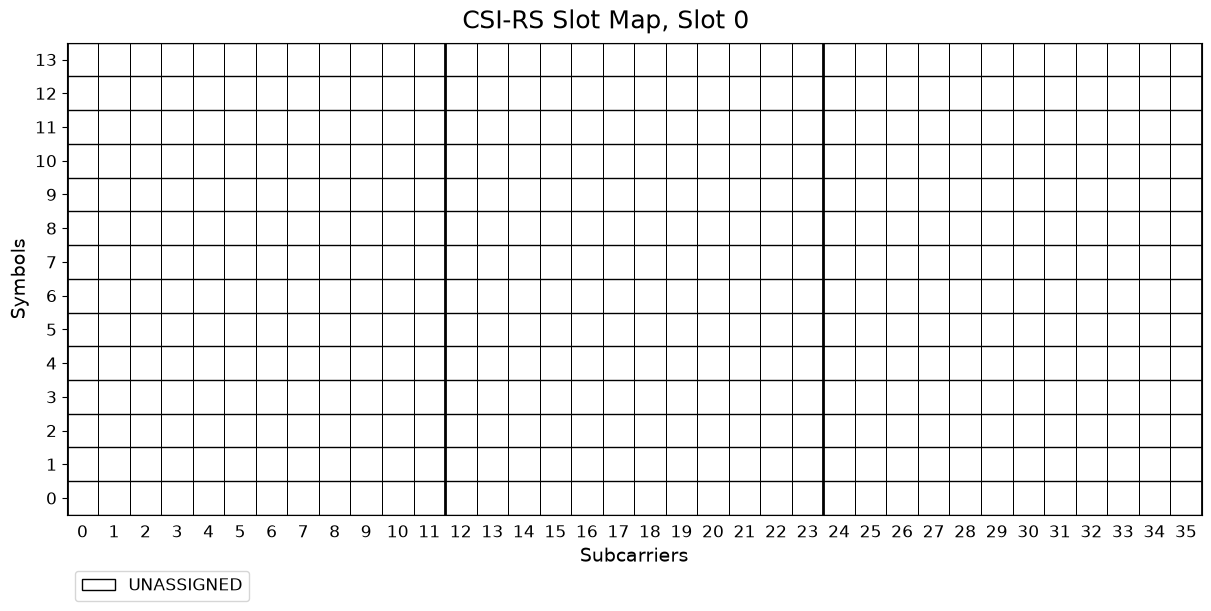

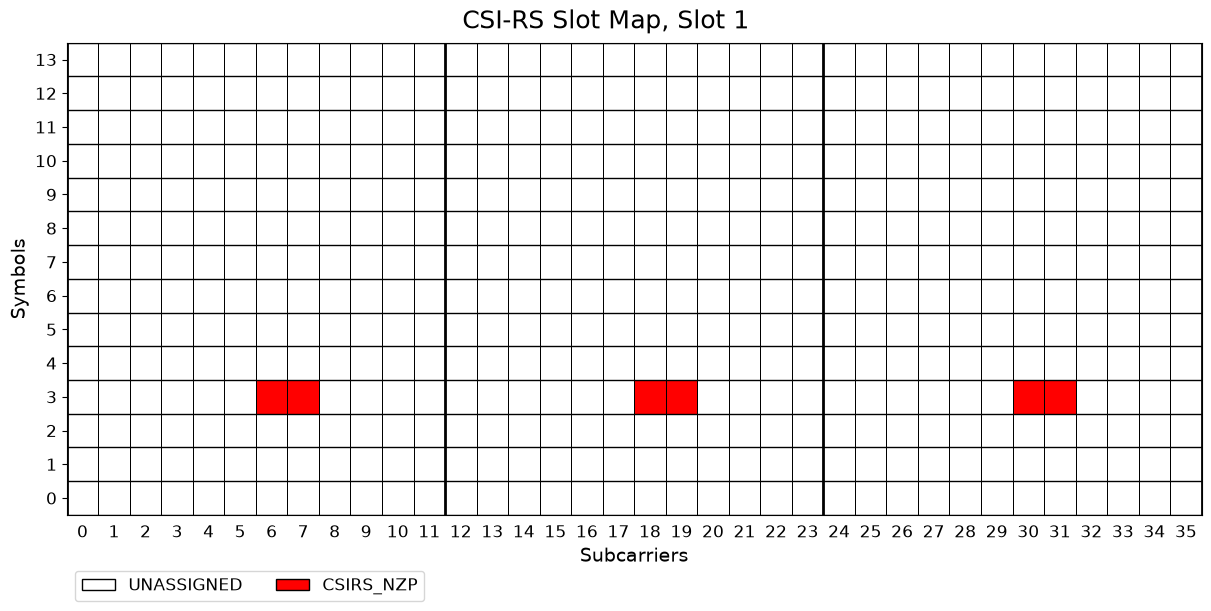

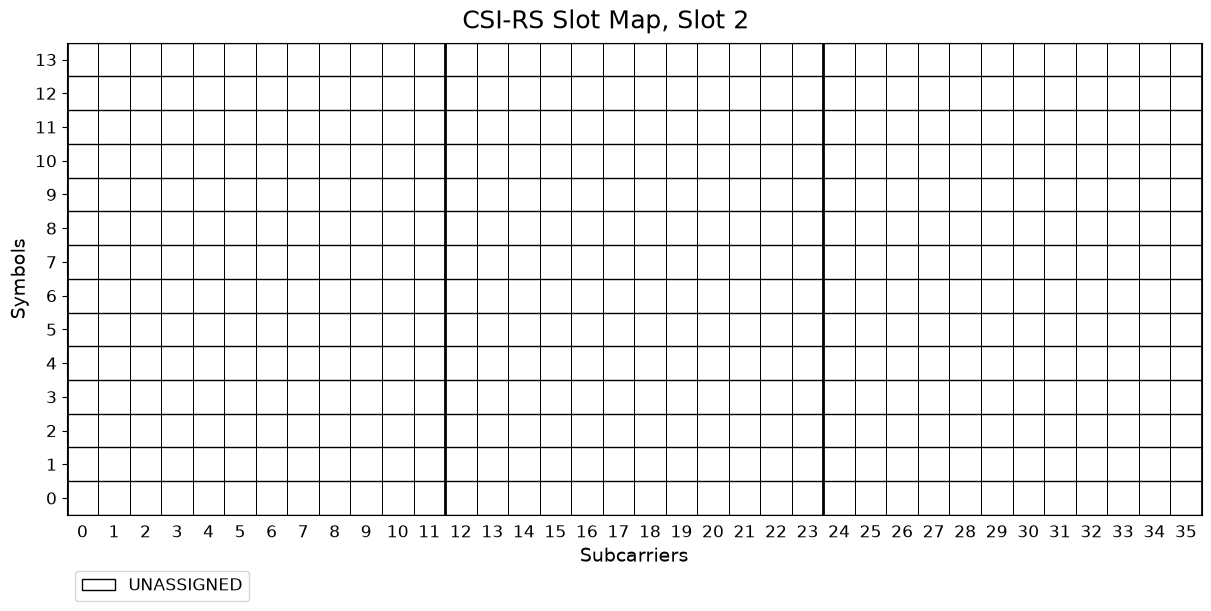

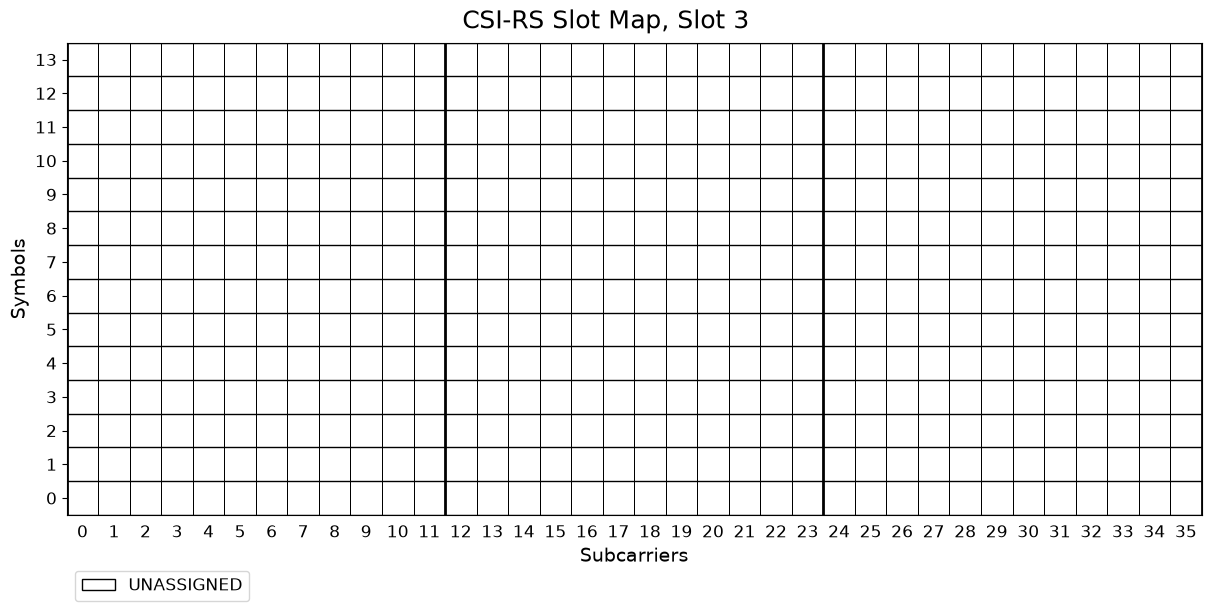

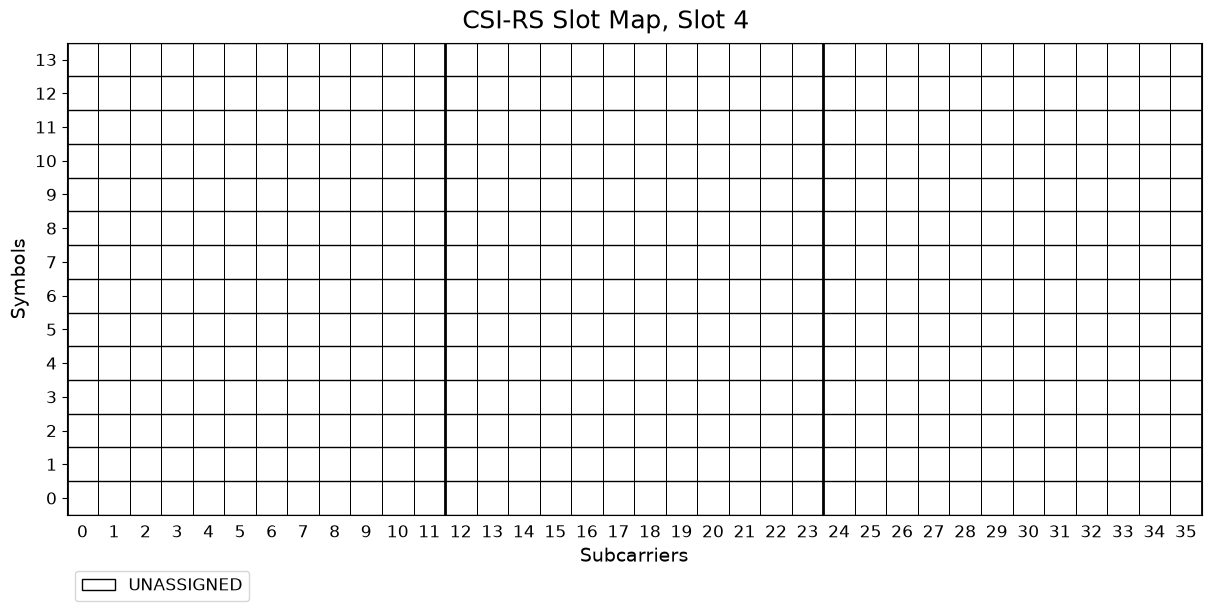

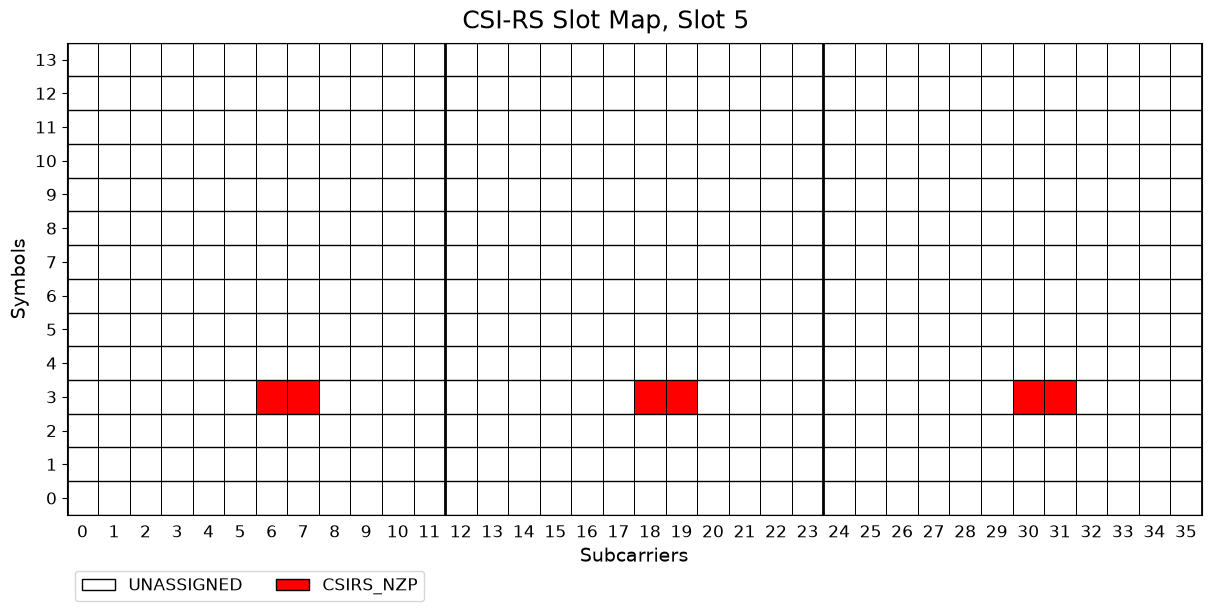

In [4]:
# Using row 3 of 3GPP 38.211 Table 7.4.1.5.3-1
# Same as before, but with `offset=1`, meaning slots 1, 5, and so on contain CSI-RS.
csiRsConfig = CsiRsConfig([CsiRsSet("NZP", bwp, symbols=[3], numPorts=2, offset=1)])
csiRsConfig.print()

carrier.slotNo = 0
for slot in range(6):
    grid = bwp.createGrid(csiRsConfig.numPorts)
    csiRsConfig.populateGrid(grid)
    # Show only the first port
    grid.drawMap(rbRange=(0,2), title="CSI-RS Slot Map, Slot %d"%(carrier.slotNo))
    carrier.slotNo += 1


CSI-RS Configuration: (1 Resource Sets)
  CSI-RS Resource Set 0:(1 NZP resources)
    Resource Set ID:      0
    Resource Type:        periodic
    Resource Blocks:      24 RBs starting at 0
    Slot Period:          5
    Num CSI-RS:           1
    CSI-RS 0:
      resourceId:         0
      numPorts:           2
      cdmSize:            2 (fd-CDM2)
      density:            1
      RE Indices:         6
      Symbol Indices:     3
      Table Row:          3
      Slot Offset:        2
      Power:              0 dB
      scramblingID:       0



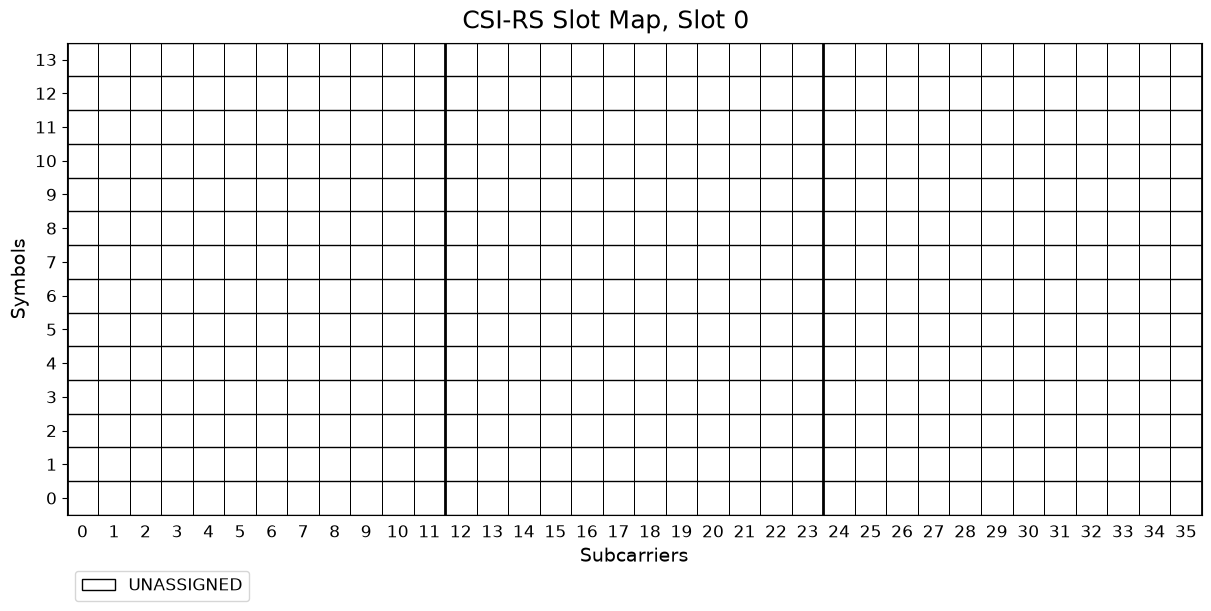

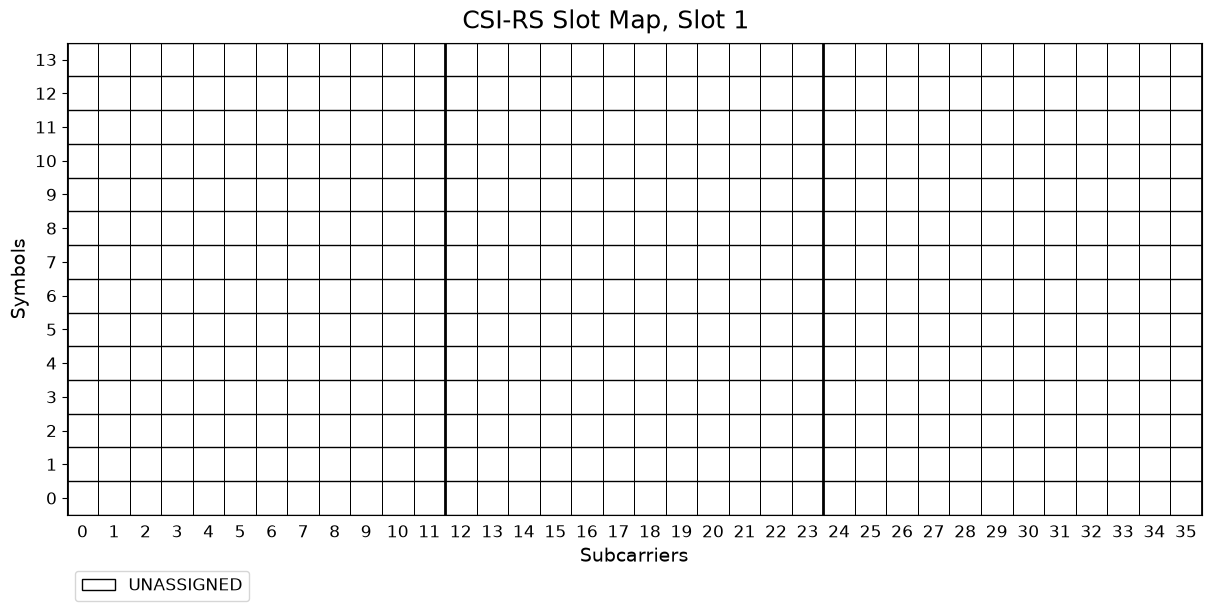

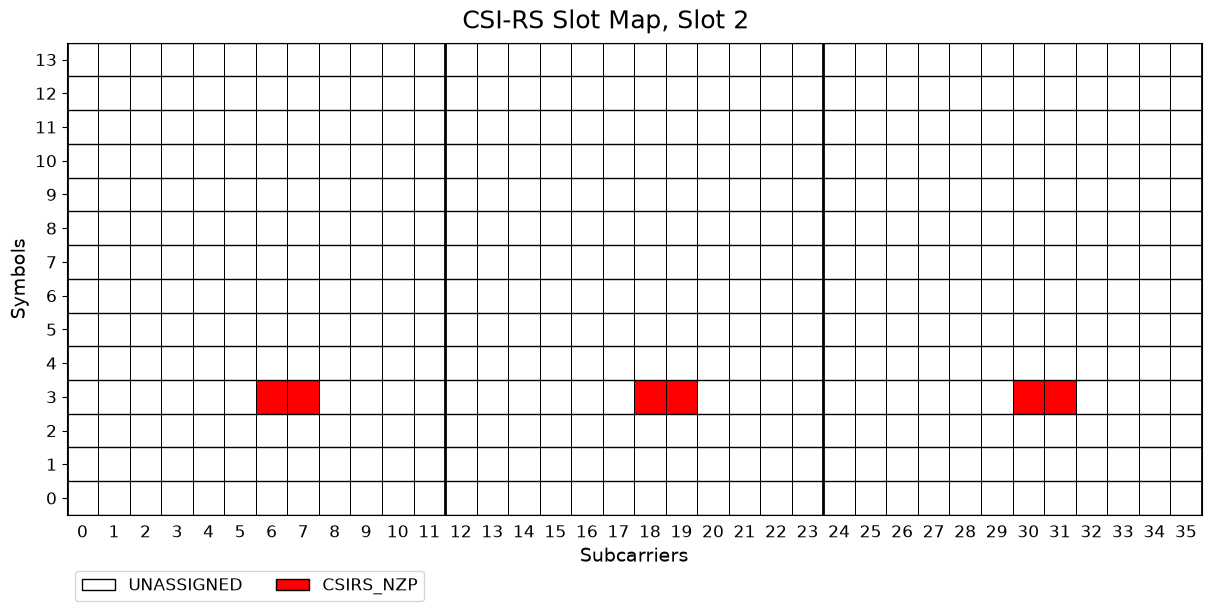

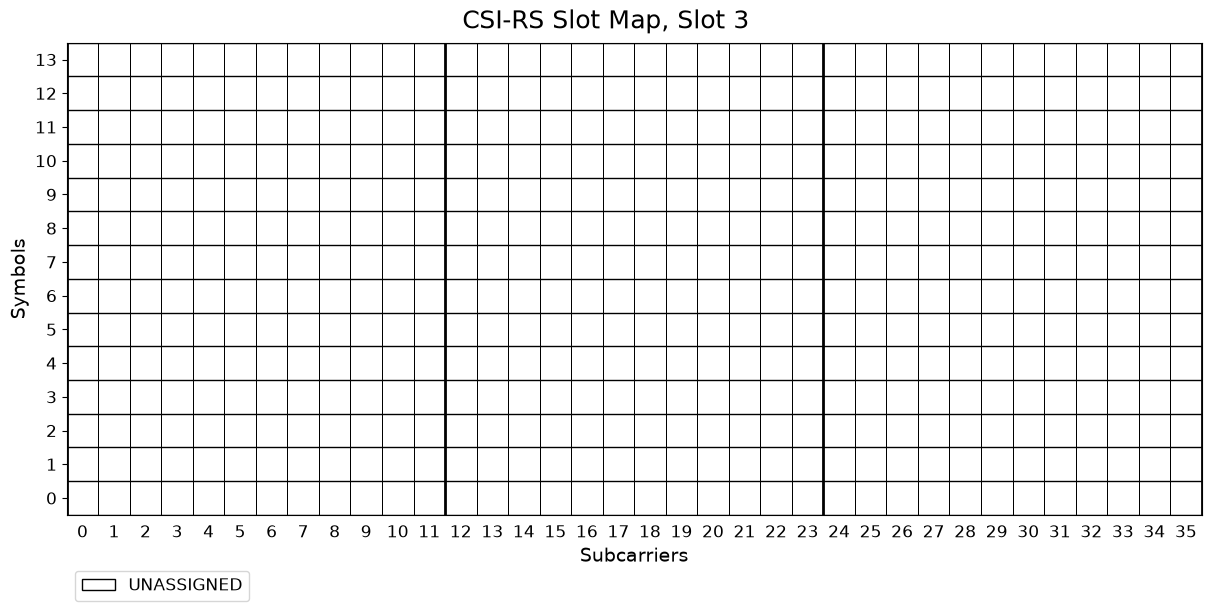

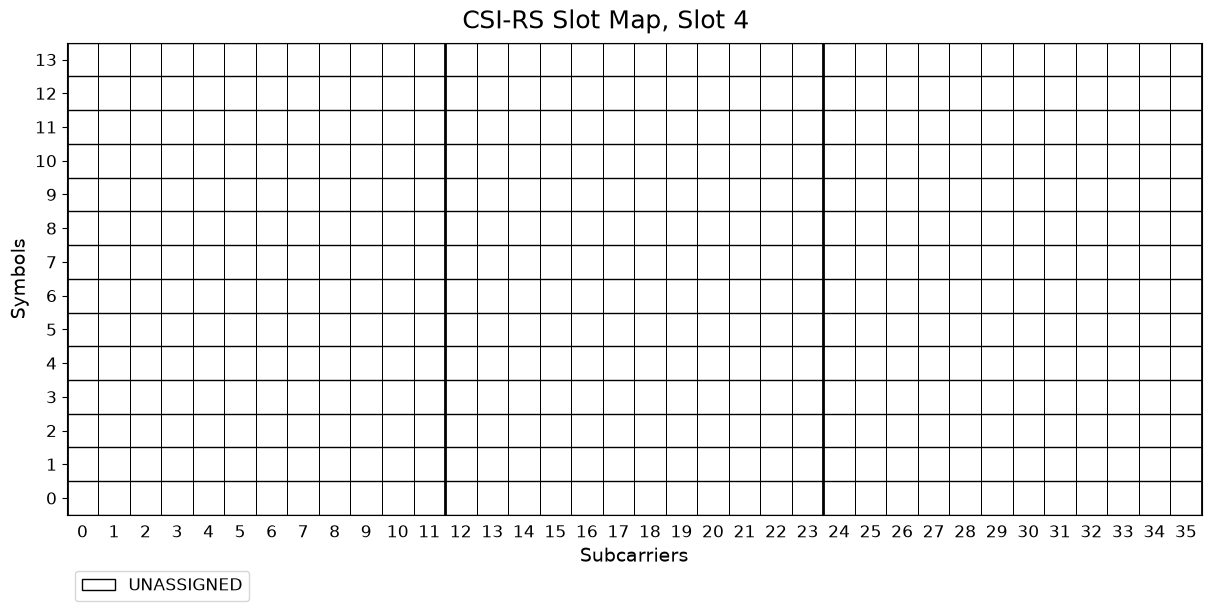

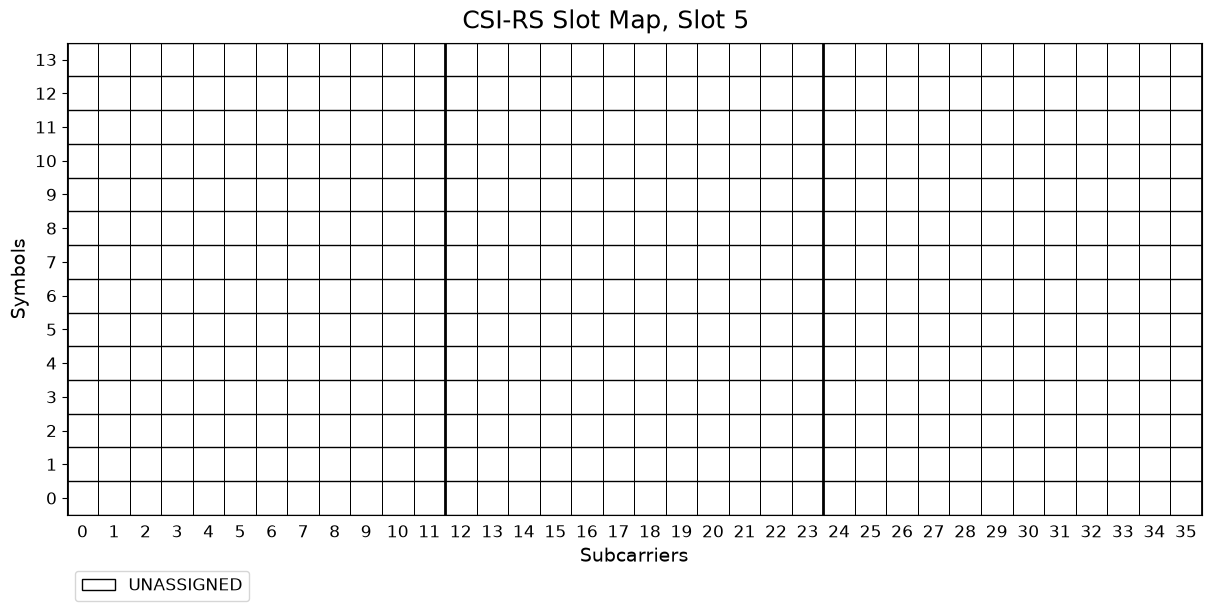

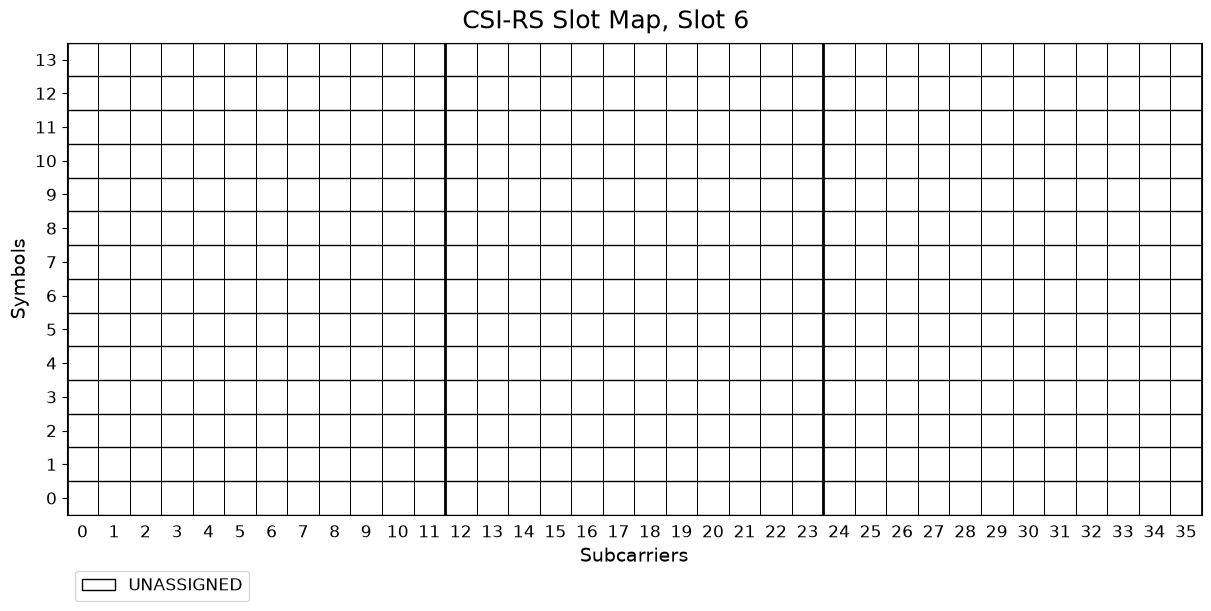

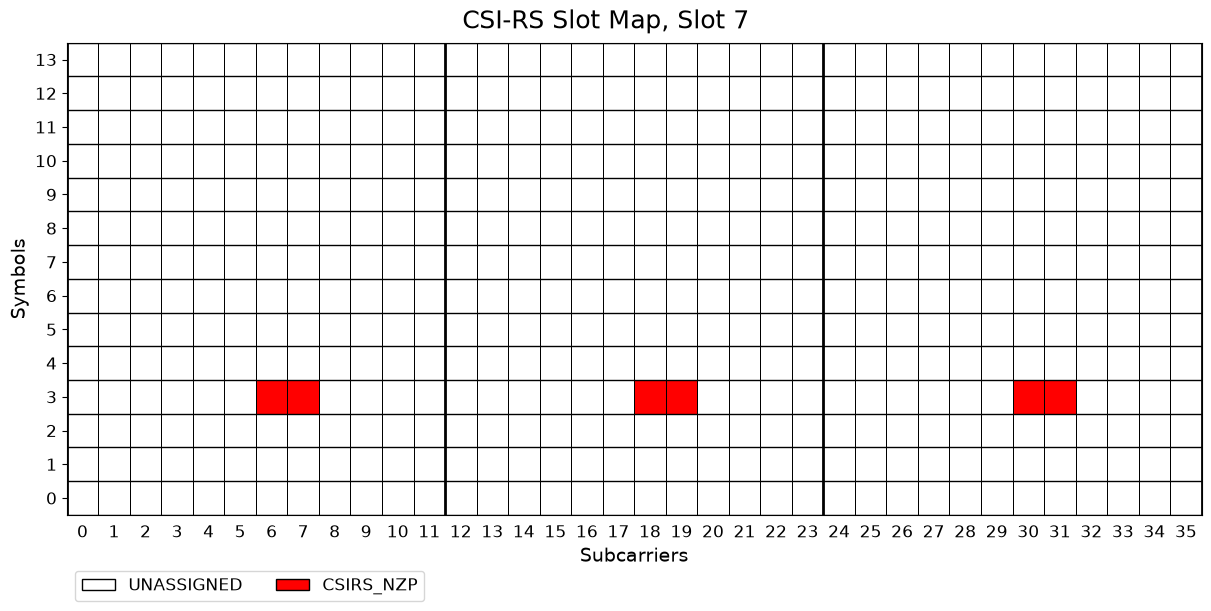

In [5]:
# Using row 3 of 3GPP 38.211 Table 7.4.1.5.3-1
# Use `period=5` and `offset=2`; slots 2, 7, and so on contain CSI-RS.
csiRsConfig = CsiRsConfig([CsiRsSet("NZP", bwp, symbols=[3], numPorts=2, period=5, offset=2)])
csiRsConfig.print()

carrier.slotNo = 0
for slot in range(8):
    grid = bwp.createGrid(csiRsConfig.numPorts)
    csiRsConfig.populateGrid(grid)
    # Show only the first port
    grid.drawMap(rbRange=(0,2), title="CSI-RS Slot Map, Slot %d"%(carrier.slotNo))
    carrier.slotNo += 1